In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [4]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### lw_1

Name: 
Type: Graph
Number of nodes: 14
Number of edges: 27
Average degree:   3.8571


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


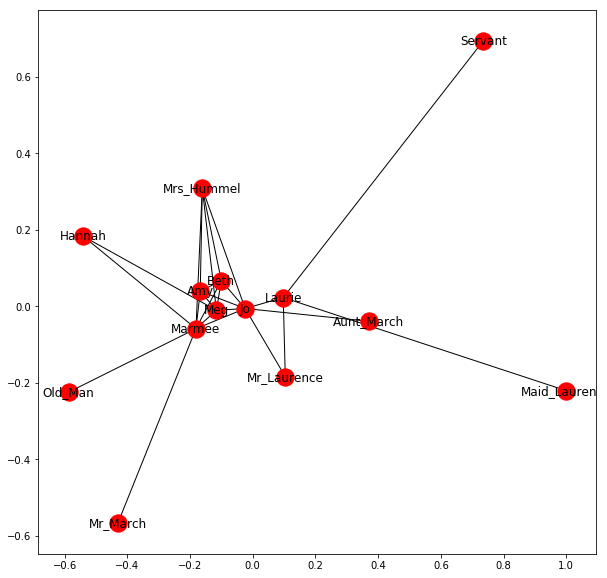

[[('Jo', 'Amy'), 0.17106728762731305], [('Jo', 'Meg'), 0.42543690662096983], [('Jo', 'Beth'), 0.14577907989110153], [('Jo', 'Marmee'), 0.14280399662801785], [('Jo', 'Mrs_Hummel'), 0.007437708157709262], [('Jo', 'Laurie'), 0.25998479844114925], [('Jo', 'Aunt_March'), 0.011044623485026465], [('Jo', 'Jo'), 0.014980445267478337], [('Jo', 'Mr_Laurence'), 0.04316413537679137], [('Amy', 'Meg'), 0.12850237006122084], [('Amy', 'Beth'), 0.09600751786183166], [('Amy', 'Marmee'), 0.09896159533450338], [('Amy', 'Mrs_Hummel'), 0.005908154945343486], [('Meg', 'Beth'), 0.10634678901618276], [('Meg', 'Marmee'), 0.11520902143419798], [('Meg', 'Mrs_Hummel'), 0.005908154945343486], [('Meg', 'Hannah'), 0.0070181451334282285], [('Beth', 'Marmee'), 0.10339271154351101], [('Beth', 'Mrs_Hummel'), 0.005908154945343486], [('Marmee', 'Mr_March'), 0.0036726966183441355], [('Marmee', 'Hannah'), 0.0011696908555713713], [('Marmee', 'Mrs_Hummel'), 0.002954077472671743], [('Marmee', 'Old_Man'), 0.006427219082102237], [

In [8]:
lw_1 = nx.read_weighted_edgelist('lw_s_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_1)
plt.show()

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf_1 = weighted_cness(lw_1,total_edge_weight)
print(w_ncf_1)

In [9]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.272947
1                    (Jo, Meg)  0.678807
2                   (Jo, Beth)  0.232598
3                 (Jo, Marmee)  0.227851
4             (Jo, Mrs_Hummel)  0.011867
5                 (Jo, Laurie)  0.414820
6             (Jo, Aunt_March)  0.017622
7                     (Jo, Jo)  0.023902
8            (Jo, Mr_Laurence)  0.068871
9                   (Amy, Meg)  0.205032
10                 (Amy, Beth)  0.153185
11               (Amy, Marmee)  0.157899
12           (Amy, Mrs_Hummel)  0.009427
13                 (Meg, Beth)  0.169682
14               (Meg, Marmee)  0.183822
15           (Meg, Mrs_Hummel)  0.009427
16               (Meg, Hannah)  0.011198
17              (Beth, Marmee)  0.164969
18          (Beth, Mrs_Hummel)  0.009427
19          (Marmee, Mr_March)  0.005860
20            (Marmee, Hannah)  0.001866
21        (Marmee, Mrs_Hummel)  0.004713
22           (Marmee, Old_Man)  0.010255
23           (La

### lw_2

Name: 
Type: Graph
Number of nodes: 30
Number of edges: 64
Average degree:   4.2667


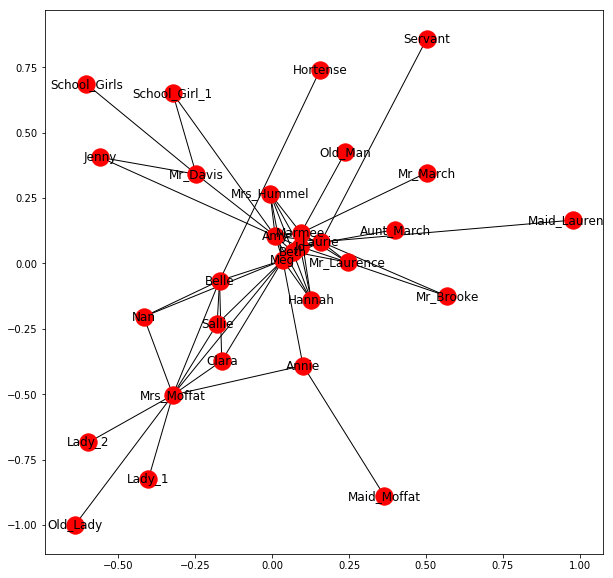

[[('Jo', 'Amy'), 0.18184641736929372], [('Jo', 'Meg'), 0.34251870753201924], [('Jo', 'Beth'), 0.13155228577353448], [('Jo', 'Marmee'), 0.1711756615636121], [('Jo', 'Mrs_Hummel'), 0.0047146607350593145], [('Jo', 'Laurie'), 0.21881419308163058], [('Jo', 'Aunt_March'), 0.006718391547459523], [('Jo', 'Jo'), 0.012342740026911693], [('Jo', 'Mr_Laurence'), 0.031090490798972262], [('Jo', 'Hannah'), 0.0037717285880474517], [('Amy', 'Meg'), 0.1570414434487139], [('Amy', 'Beth'), 0.07930394125179356], [('Amy', 'Marmee'), 0.08396234222857457], [('Amy', 'Mrs_Hummel'), 0.0037624294544477297], [('Amy', 'Hannah'), 0.0037624294544477297], [('Amy', 'Amy'), 0.0009447919737318075], [('Amy', 'Mr_Davis'), 0.010319016077272083], [('Amy', 'Jenny'), 0.0006070009457218872], [('Amy', 'School_Girl_1'), 0.0006070009457218872], [('Amy', 'Laurie'), 0.011290078103423105], [('Meg', 'Beth'), 0.08844940666878066], [('Meg', 'Marmee'), 0.11784606028256348], [('Meg', 'Mrs_Hummel'), 0.0037903268552468964], [('Meg', 'Hannah'

In [13]:
lw_2 = nx.read_weighted_edgelist('lw_s_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_2)
plt.show()

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf_2 = weighted_cness(lw_2,total_edge_weight)
print(w_ncf_2)

In [14]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.324127
1                    (Jo, Meg)  0.610513
2                   (Jo, Beth)  0.234482
3                 (Jo, Marmee)  0.305107
4             (Jo, Mrs_Hummel)  0.008404
5                 (Jo, Laurie)  0.390019
6             (Jo, Aunt_March)  0.011975
7                     (Jo, Jo)  0.022000
8            (Jo, Mr_Laurence)  0.055416
9                 (Jo, Hannah)  0.006723
10                  (Amy, Meg)  0.279914
11                 (Amy, Beth)  0.141353
12               (Amy, Marmee)  0.149656
13           (Amy, Mrs_Hummel)  0.006706
14               (Amy, Hannah)  0.006706
15                  (Amy, Amy)  0.001684
16             (Amy, Mr_Davis)  0.018393
17                (Amy, Jenny)  0.001082
18        (Amy, School_Girl_1)  0.001082
19               (Amy, Laurie)  0.020124
20                 (Meg, Beth)  0.157654
21               (Meg, Marmee)  0.210052
22           (Meg, Mrs_Hummel)  0.006756
23              

### lw_3

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 119
Average degree:   6.8000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


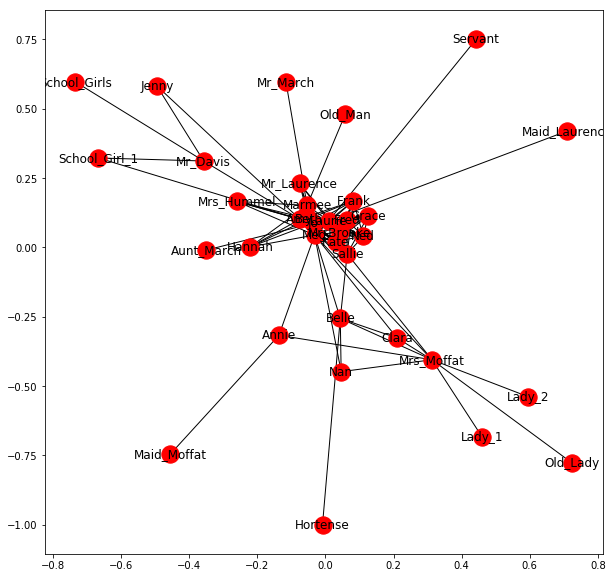

[[('Jo', 'Amy'), 0.1227362010942973], [('Jo', 'Meg'), 0.252830177880543], [('Jo', 'Beth'), 0.11501385041551247], [('Jo', 'Marmee'), 0.11665340766008105], [('Jo', 'Mrs_Hummel'), 0.002215494150774936], [('Jo', 'Laurie'), 0.22165964607037383], [('Jo', 'Aunt_March'), 0.0031451889837686865], [('Jo', 'Jo'), 0.009528170142624939], [('Jo', 'Mr_Laurence'), 0.015318158924933038], [('Jo', 'Hannah'), 0.0017723953206199492], [('Jo', 'Mr_Brooke'), 0.008536205672947047], [('Jo', 'Ned'), 0.0047377578352143955], [('Jo', 'Fred'), 0.018951031340857582], [('Jo', 'Kate'), 0.01042306723747167], [('Jo', 'Sallie'), 0.008555779400654747], [('Jo', 'Grace'), 0.0027938920812252467], [('Jo', 'Frank'), 0.0028426547011286374], [('Amy', 'Meg'), 0.0990810649939333], [('Amy', 'Beth'), 0.05884755385636776], [('Amy', 'Marmee'), 0.05435652800988988], [('Amy', 'Mrs_Hummel'), 0.0017696481307662372], [('Amy', 'Hannah'), 0.0017696481307662372], [('Amy', 'Amy'), 0.00047503491220439095], [('Amy', 'Mr_Davis'), 0.0049154094457544

In [15]:
lw_3 = nx.read_weighted_edgelist('lw_s_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_3)
plt.show()

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf_3 = weighted_cness(lw_3,total_edge_weight)
print(w_ncf_3)

In [16]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.274327
1                    (Jo, Meg)  0.565100
2                   (Jo, Beth)  0.257067
3                 (Jo, Marmee)  0.260732
4             (Jo, Mrs_Hummel)  0.004952
5                 (Jo, Laurie)  0.495431
6             (Jo, Aunt_March)  0.007030
7                     (Jo, Jo)  0.021296
8            (Jo, Mr_Laurence)  0.034238
9                 (Jo, Hannah)  0.003961
10             (Jo, Mr_Brooke)  0.019079
11                   (Jo, Ned)  0.010589
12                  (Jo, Fred)  0.042357
13                  (Jo, Kate)  0.023297
14                (Jo, Sallie)  0.019123
15                 (Jo, Grace)  0.006245
16                 (Jo, Frank)  0.006354
17                  (Amy, Meg)  0.221456
18                 (Amy, Beth)  0.131530
19               (Amy, Marmee)  0.121492
20           (Amy, Mrs_Hummel)  0.003955
21               (Amy, Hannah)  0.003955
22                  (Amy, Amy)  0.001062
23             (

### lw_4

Name: 
Type: Graph
Number of nodes: 37
Number of edges: 124
Average degree:   6.7027


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


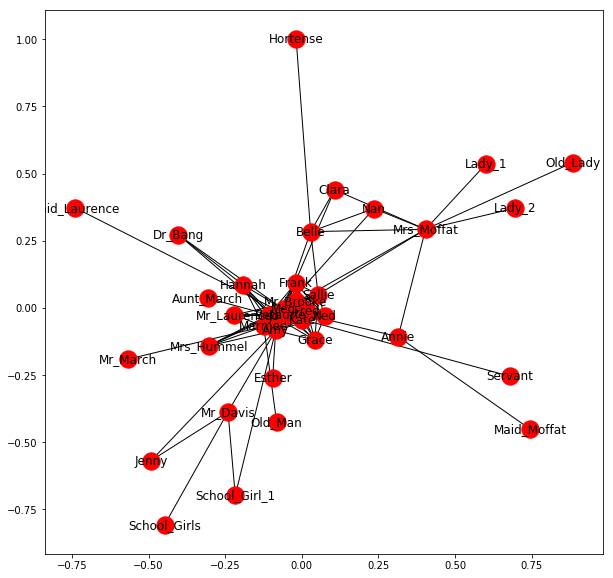

[[('Jo', 'Amy'), 0.11164093558134523], [('Jo', 'Meg'), 0.24476557735603355], [('Jo', 'Beth'), 0.12559436743714725], [('Jo', 'Marmee'), 0.14378097932495448], [('Jo', 'Mrs_Hummel'), 0.001999642347848814], [('Jo', 'Laurie'), 0.2304761358894763], [('Jo', 'Aunt_March'), 0.006948355946425542], [('Jo', 'Jo'), 0.008960837089445135], [('Jo', 'Mr_Laurence'), 0.01377121267005672], [('Jo', 'Hannah'), 0.005599640513735219], [('Jo', 'Mr_Brooke'), 0.007662559780640014], [('Jo', 'Ned'), 0.0042445973891392964], [('Jo', 'Fred'), 0.016978389556557186], [('Jo', 'Kate'), 0.009338114256106452], [('Jo', 'Sallie'), 0.007662559780640014], [('Jo', 'Grace'), 0.0025032899412625116], [('Jo', 'Frank'), 0.0025467584334835777], [('Jo', 'Dr_Bang'), 0.0007220905226765218], [('Amy', 'Meg'), 0.09000605257486623], [('Amy', 'Beth'), 0.05314344143904553], [('Amy', 'Marmee'), 0.0657533392330654], [('Amy', 'Mrs_Hummel'), 0.001597329530604478], [('Amy', 'Hannah'), 0.0023962694129460904], [('Amy', 'Amy'), 0.0004255143542315293]

In [17]:
lw_4 = nx.read_weighted_edgelist('lw_s_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_4)
plt.show()

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf_4 = weighted_cness(lw_4,total_edge_weight)
print(w_ncf_4)

In [18]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.246196
1                    (Jo, Meg)  0.539769
2                   (Jo, Beth)  0.276967
3                 (Jo, Marmee)  0.317073
4             (Jo, Mrs_Hummel)  0.004410
5                 (Jo, Laurie)  0.508257
6             (Jo, Aunt_March)  0.015323
7                     (Jo, Jo)  0.019761
8            (Jo, Mr_Laurence)  0.030369
9                 (Jo, Hannah)  0.012349
10             (Jo, Mr_Brooke)  0.016898
11                   (Jo, Ned)  0.009360
12                  (Jo, Fred)  0.037442
13                  (Jo, Kate)  0.020593
14                (Jo, Sallie)  0.016898
15                 (Jo, Grace)  0.005520
16                 (Jo, Frank)  0.005616
17               (Jo, Dr_Bang)  0.001592
18                  (Amy, Meg)  0.198486
19                 (Amy, Beth)  0.117195
20               (Amy, Marmee)  0.145003
21           (Amy, Mrs_Hummel)  0.003523
22               (Amy, Hannah)  0.005284
23              

### lw_5

Name: 
Type: Graph
Number of nodes: 37
Number of edges: 131
Average degree:   7.0811


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


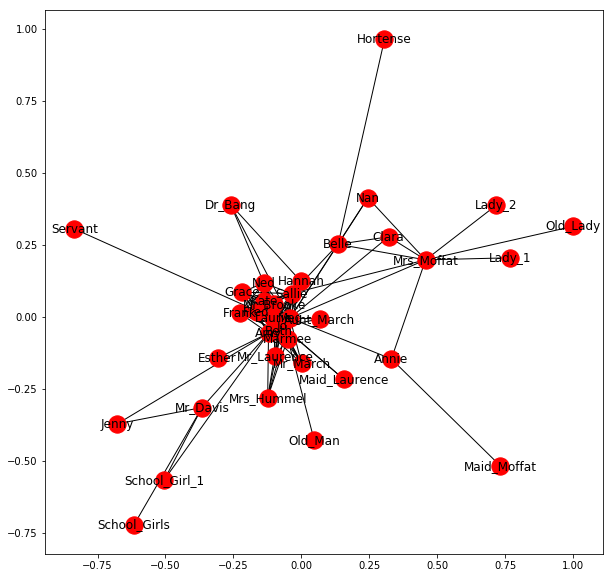

[[('Jo', 'Amy'), 0.10182782872971485], [('Jo', 'Meg'), 0.24483377579825488], [('Jo', 'Beth'), 0.11682509460816119], [('Jo', 'Marmee'), 0.1392521823389914], [('Jo', 'Mrs_Hummel'), 0.001827280960975255], [('Jo', 'Laurie'), 0.250430876779422], [('Jo', 'Aunt_March'), 0.007289555277893469], [('Jo', 'Jo'), 0.01008332695843852], [('Jo', 'Mr_Laurence'), 0.0324761508101783], [('Jo', 'Hannah'), 0.00511691557089308], [('Jo', 'Mr_Brooke'), 0.00889640654262538], [('Jo', 'Ned'), 0.003857425241372406], [('Jo', 'Fred'), 0.015429700965489623], [('Jo', 'Kate'), 0.008486335531019292], [('Jo', 'Sallie'), 0.006961725131535329], [('Jo', 'Grace'), 0.002274789132645978], [('Jo', 'Frank'), 0.0023144551448234436], [('Jo', 'Dr_Bang'), 0.0006641223753141406], [('Jo', 'Maid_Laurence'), 0.003134370505108888], [('Jo', 'Mr_March'), 0.005621240582863716], [('Amy', 'Meg'), 0.08444599330777709], [('Amy', 'Beth'), 0.04904687294881857], [('Amy', 'Marmee'), 0.060985435962528846], [('Amy', 'Mrs_Hummel'), 0.00145925592227728

In [19]:
lw_5 = nx.read_weighted_edgelist('lw_s_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_5)
plt.show()

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf_5 = weighted_cness(lw_5,total_edge_weight)
print(w_ncf_5)

In [20]:
edge_w = list(w_ncf_5)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.223789
1                    (Jo, Meg)  0.538077
2                   (Jo, Beth)  0.256749
3                 (Jo, Marmee)  0.306038
4             (Jo, Mrs_Hummel)  0.004016
5                 (Jo, Laurie)  0.550378
6             (Jo, Aunt_March)  0.016020
7                     (Jo, Jo)  0.022160
8            (Jo, Mr_Laurence)  0.071374
9                 (Jo, Hannah)  0.011246
10             (Jo, Mr_Brooke)  0.019552
11                   (Jo, Ned)  0.008478
12                  (Jo, Fred)  0.033910
13                  (Jo, Kate)  0.018651
14                (Jo, Sallie)  0.015300
15                 (Jo, Grace)  0.004999
16                 (Jo, Frank)  0.005087
17               (Jo, Dr_Bang)  0.001460
18         (Jo, Maid_Laurence)  0.006888
19              (Jo, Mr_March)  0.012354
20                  (Amy, Meg)  0.185589
21                 (Amy, Beth)  0.107791
22               (Amy, Marmee)  0.134029
23           (Am

### lw_6

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 140
Average degree:   6.5116


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


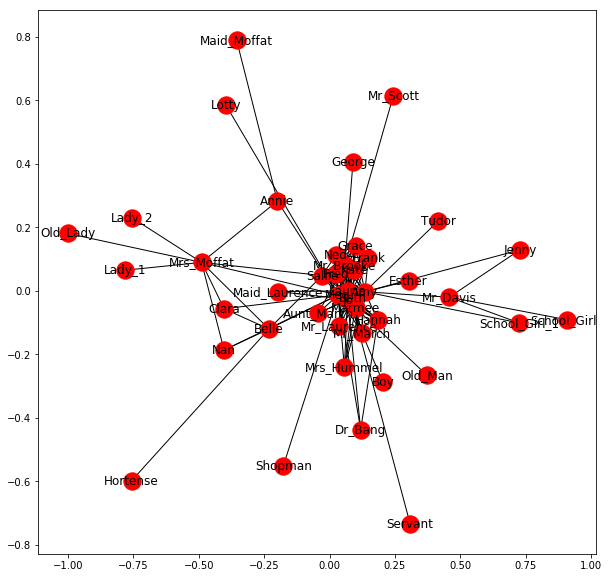

[[('Jo', 'Amy'), 0.10153058674515789], [('Jo', 'Meg'), 0.22853026168673238], [('Jo', 'Beth'), 0.1089140019140483], [('Jo', 'Marmee'), 0.13636923160304168], [('Jo', 'Mrs_Hummel'), 0.0016853697760087964], [('Jo', 'Laurie'), 0.26497694232635227], [('Jo', 'Aunt_March'), 0.007303844240899099], [('Jo', 'Jo'), 0.009275733270068587], [('Jo', 'Mr_Laurence'), 0.029929278381799592], [('Jo', 'Hannah'), 0.004835803312937185], [('Jo', 'Mr_Brooke'), 0.008185611556587584], [('Jo', 'Ned'), 0.003549055125588489], [('Jo', 'Fred'), 0.014196220502353956], [('Jo', 'Kate'), 0.007807921276294676], [('Jo', 'Sallie'), 0.006403829937305778], [('Jo', 'Grace'), 0.0020958790695736235], [('Jo', 'Frank'), 0.0021294330753530936], [('Jo', 'Dr_Bang'), 0.0006129837512969422], [('Jo', 'Maid_Laurence'), 0.0028690272751245686], [('Jo', 'Mr_March'), 0.007598416455446864], [('Jo', 'Boy'), 0.0029088127391202253], [('Amy', 'Meg'), 0.08343673293146073], [('Amy', 'Beth'), 0.046915019143678766], [('Amy', 'Marmee'), 0.0712272930456

In [21]:
lw_6 = nx.read_weighted_edgelist('lw_s_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_6)
plt.show()

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf_6 = weighted_cness(lw_6,total_edge_weight)
print(w_ncf_6)

In [22]:
edge_w = list(w_ncf_6)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0                    (Jo, Amy)  0.223077
1                    (Jo, Meg)  0.502114
2                   (Jo, Beth)  0.239300
3                 (Jo, Marmee)  0.299623
4             (Jo, Mrs_Hummel)  0.003703
5                 (Jo, Laurie)  0.582192
6             (Jo, Aunt_March)  0.016048
7                     (Jo, Jo)  0.020380
8            (Jo, Mr_Laurence)  0.065759
9                 (Jo, Hannah)  0.010625
10             (Jo, Mr_Brooke)  0.017985
11                   (Jo, Ned)  0.007798
12                  (Jo, Fred)  0.031191
13                  (Jo, Kate)  0.017155
14                (Jo, Sallie)  0.014070
15                 (Jo, Grace)  0.004605
16                 (Jo, Frank)  0.004679
17               (Jo, Dr_Bang)  0.001347
18         (Jo, Maid_Laurence)  0.006304
19              (Jo, Mr_March)  0.016695
20                   (Jo, Boy)  0.006391
21                  (Amy, Meg)  0.183322
22                 (Amy, Beth)  0.103079
23              

### lw_7

Name: 
Type: Graph
Number of nodes: 59
Number of edges: 163
Average degree:   5.5254


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


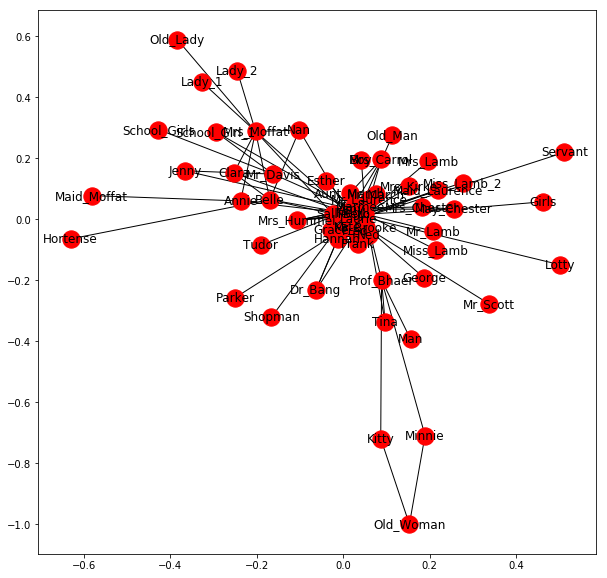

[[('Jo', 'Amy'), 0.14633174929437323], [('Jo', 'Meg'), 0.206533757225999], [('Jo', 'Beth'), 0.10838269378907993], [('Jo', 'Marmee'), 0.15822863863024694], [('Jo', 'Mrs_Hummel'), 0.001530493907464994], [('Jo', 'Laurie'), 0.263527430356184], [('Jo', 'Aunt_March'), 0.007249691462002016], [('Jo', 'Jo'), 0.013590032553142417], [('Jo', 'Mr_Laurence'), 0.027169445032341397], [('Jo', 'Hannah'), 0.004381696025285611], [('Jo', 'Mr_Brooke'), 0.007400046597536263], [('Jo', 'Ned'), 0.003207471593460221], [('Jo', 'Fred'), 0.012829886373840884], [('Jo', 'Kate'), 0.0070564375056124855], [('Jo', 'Sallie'), 0.005786161567579415], [('Jo', 'Grace'), 0.0018967033537905776], [('Jo', 'Frank'), 0.0019244829560761325], [('Jo', 'Dr_Bang'), 0.0005593064558095454], [('Jo', 'Maid_Laurence'), 0.0026377543262479913], [('Jo', 'Mr_March'), 0.006884946853461734], [('Jo', 'Boy'), 0.002697524939451845], [('Jo', 'Miss_Lamb'), 0.00220706585955151], [('Jo', 'Miss_Lamb_2'), 0.0017166067796511744], [('Jo', 'Mr_Lamb'), 0.00318

In [23]:
lw_7 = nx.read_weighted_edgelist('lw_s_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_7)
plt.show()

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf_7 = weighted_cness(lw_7,total_edge_weight)
print(w_ncf_7)

In [24]:
edge_w = list(w_ncf_7)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                          Edges        IF
0                     (Jo, Amy)  0.321764
1                     (Jo, Meg)  0.454140
2                    (Jo, Beth)  0.238319
3                  (Jo, Marmee)  0.347923
4              (Jo, Mrs_Hummel)  0.003365
5                  (Jo, Laurie)  0.579461
6              (Jo, Aunt_March)  0.015941
7                      (Jo, Jo)  0.029883
8             (Jo, Mr_Laurence)  0.059742
9                  (Jo, Hannah)  0.009635
10              (Jo, Mr_Brooke)  0.016272
11                    (Jo, Ned)  0.007053
12                   (Jo, Fred)  0.028211
13                   (Jo, Kate)  0.015516
14                 (Jo, Sallie)  0.012723
15                  (Jo, Grace)  0.004171
16                  (Jo, Frank)  0.004232
17                (Jo, Dr_Bang)  0.001230
18          (Jo, Maid_Laurence)  0.005800
19               (Jo, Mr_March)  0.015139
20                    (Jo, Boy)  0.005931
21              (Jo, Miss_Lamb)  0.004853
22            (Jo, Miss_Lamb_2)  0

### lw_8

Name: 
Type: Graph
Number of nodes: 61
Number of edges: 168
Average degree:   5.5082


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


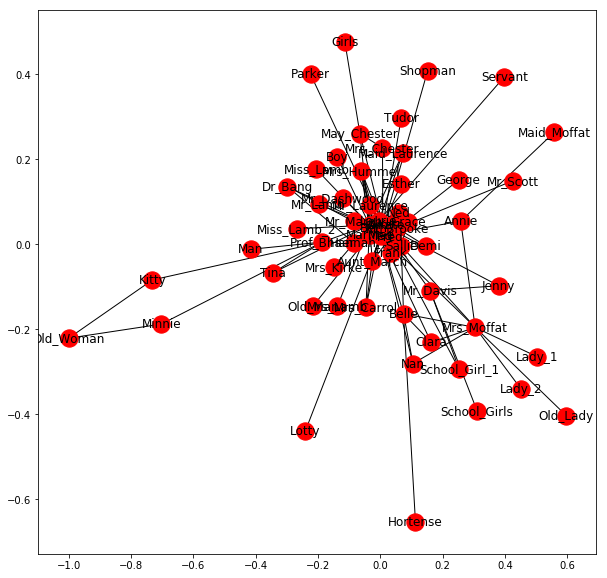

[[('Jo', 'Amy'), 0.13451837355062232], [('Jo', 'Meg'), 0.18979833509020808], [('Jo', 'Beth'), 0.1206016119143357], [('Jo', 'Marmee'), 0.14621225555554407], [('Jo', 'Mrs_Hummel'), 0.001405932328435733], [('Jo', 'Laurie'), 0.2694046977911896], [('Jo', 'Aunt_March'), 0.006672993600407178], [('Jo', 'Jo'), 0.020252815334126168], [('Jo', 'Mr_Laurence'), 0.02508961842633714], [('Jo', 'Hannah'), 0.004033293797145331], [('Jo', 'Mr_Brooke'), 0.006802667077270019], [('Jo', 'Ned'), 0.0029486640167912196], [('Jo', 'Fred'), 0.011794656067164878], [('Jo', 'Kate'), 0.006487060836940684], [('Jo', 'Sallie'), 0.005318284054809565], [('Jo', 'Grace'), 0.0017458413489437386], [('Jo', 'Frank'), 0.0017691984100747318], [('Jo', 'Dr_Bang'), 0.000513811357949403], [('Jo', 'Maid_Laurence'), 0.0024342368417875153], [('Jo', 'Mr_March'), 0.006337549253542856], [('Jo', 'Boy'), 0.0024725054730190864], [('Jo', 'Miss_Lamb'), 0.0020229590233792525], [('Jo', 'Miss_Lamb_2'), 0.0015734125737394183], [('Jo', 'Mr_Lamb'), 0.00

In [25]:
lw_8 = nx.read_weighted_edgelist('lw_s_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_8)
plt.show()

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf_8 = weighted_cness(lw_8,total_edge_weight)
print(w_ncf_8)

In [26]:
edge_w = list(w_ncf_8)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                          Edges        IF
0                     (Jo, Amy)  0.299470
1                     (Jo, Meg)  0.422537
2                    (Jo, Beth)  0.268488
3                  (Jo, Marmee)  0.325504
4              (Jo, Mrs_Hummel)  0.003130
5                  (Jo, Laurie)  0.599760
6              (Jo, Aunt_March)  0.014856
7                      (Jo, Jo)  0.045088
8             (Jo, Mr_Laurence)  0.055856
9                  (Jo, Hannah)  0.008979
10              (Jo, Mr_Brooke)  0.015144
11                    (Jo, Ned)  0.006564
12                   (Jo, Fred)  0.026258
13                   (Jo, Kate)  0.014442
14                 (Jo, Sallie)  0.011840
15                  (Jo, Grace)  0.003887
16                  (Jo, Frank)  0.003939
17                (Jo, Dr_Bang)  0.001144
18          (Jo, Maid_Laurence)  0.005419
19               (Jo, Mr_March)  0.014109
20                    (Jo, Boy)  0.005504
21              (Jo, Miss_Lamb)  0.004504
22            (Jo, Miss_Lamb_2)  0

### lw_9

Name: 
Type: Graph
Number of nodes: 64
Number of edges: 180
Average degree:   5.6250


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


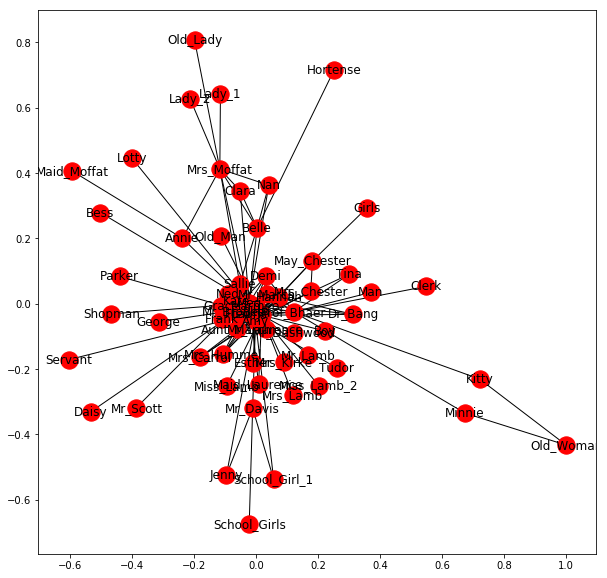

[[('Jo', 'Amy'), 0.1255305466237942], [('Jo', 'Meg'), 0.17359919769233154], [('Jo', 'Beth'), 0.1088430764777039], [('Jo', 'Marmee'), 0.1485178192946723], [('Jo', 'Mrs_Hummel'), 0.001225876490110731], [('Jo', 'Laurie'), 0.2857692538331903], [('Jo', 'Aunt_March'), 0.005817508090280291], [('Jo', 'Jo'), 0.02330000723731144], [('Jo', 'Mr_Laurence'), 0.0284535023417872], [('Jo', 'Hannah'), 0.005515046370488311], [('Jo', 'Mr_Brooke'), 0.0059080282461926575], [('Jo', 'Ned'), 0.0025549777194197746], [('Jo', 'Fred'), 0.010219910877679098], [('Jo', 'Kate'), 0.005620950982723504], [('Jo', 'Sallie'), 0.004606999514066232], [('Jo', 'Grace'), 0.0015150215568490812], [('Jo', 'Frank'), 0.0015329866316518646], [('Jo', 'Dr_Bang'), 0.0004422783056420011], [('Jo', 'Maid_Laurence'), 0.002160275431395457], [('Jo', 'Mr_March'), 0.014592438043444546], [('Jo', 'Boy'), 0.002162492116500036], [('Jo', 'Miss_Lamb'), 0.001769311731681848], [('Jo', 'Miss_Lamb_2'), 0.0013761313468636594], [('Jo', 'Mr_Lamb'), 0.0025556

In [32]:
lw_9 = nx.read_weighted_edgelist('lw_s_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_9)
plt.show()

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf_9 = weighted_cness(lw_9,total_edge_weight)
print(w_ncf_9)

In [33]:
edge_w = list(w_ncf_9)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('lw_n_t9.csv')
print(df_2)

                          Edges        IF
0                     (Jo, Amy)  0.274231
1                     (Jo, Meg)  0.379240
2                    (Jo, Beth)  0.237776
3                  (Jo, Marmee)  0.324448
4              (Jo, Mrs_Hummel)  0.002678
5                  (Jo, Laurie)  0.624284
6              (Jo, Aunt_March)  0.012709
7                      (Jo, Jo)  0.050901
8             (Jo, Mr_Laurence)  0.062159
9                  (Jo, Hannah)  0.012048
10              (Jo, Mr_Brooke)  0.012907
11                    (Jo, Ned)  0.005582
12                   (Jo, Fred)  0.022326
13                   (Jo, Kate)  0.012279
14                 (Jo, Sallie)  0.010064
15                  (Jo, Grace)  0.003310
16                  (Jo, Frank)  0.003349
17                (Jo, Dr_Bang)  0.000966
18          (Jo, Maid_Laurence)  0.004719
19               (Jo, Mr_March)  0.031878
20                    (Jo, Boy)  0.004724
21              (Jo, Miss_Lamb)  0.003865
22            (Jo, Miss_Lamb_2)  0